In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atulmittal199174/credit-risk-analysis-for-extending-bank-loans/bankloans.csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

%matplotlib inline

In [4]:
df=pd.read_csv('/kaggle/input/datasets/atulmittal199174/credit-risk-analysis-for-extending-bank-loans/bankloans.csv')

In [5]:
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [6]:
df.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     450
dtype: int64

In [7]:
df.value_counts()

age  ed  employ  address  income  debtinc  creddebt  othdebt   default
56   1   11      20       59      15.0     4.672800  4.177200  0.0        1
20   1   4       0        14      9.7      0.200984  1.157016  1.0        1
     3   0       1        17      2.3      0.043792  0.347208  0.0        1
21   1   1       1        16      6.3      0.141120  0.866880  0.0        1
                          18      17.3     0.158814  2.955186  0.0        1
                                                                         ..
22   1   4       3        14      17.5     0.225400  2.224600  0.0        1
                 2        24      15.6     1.636128  2.107872  1.0        1
                 1        16      1.2      0.084480  0.107520  0.0        1
         1       3        17      18.6     0.806310  2.355690  0.0        1
                 0        18      4.4      0.270072  0.521928  0.0        1
Name: count, Length: 700, dtype: int64

In [8]:
df=df.dropna()

In [9]:
df.isnull().sum()

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64

In [19]:
df.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,34.860000,1.722857,8.388571,8.278571,45.601429,10.260571,1.553553,3.058209,0.261429
std,7.997342,0.928206,6.658039,6.824877,36.814226,6.827234,2.117197,3.287555,0.439727
min,20.000000,1.000000,0.000000,0.000000,14.000000,0.400000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.000000,0.369059,1.044178,0.000000
50%,34.000000,1.000000,7.000000,7.000000,34.000000,8.600000,0.854869,1.987567,0.000000
75%,40.000000,2.000000,12.000000,12.000000,55.000000,14.125000,1.901955,3.923065,1.000000
max,56.000000,5.000000,31.000000,34.000000,446.000000,41.300000,20.561310,27.033600,1.000000


<Axes: xlabel='age', ylabel='income'>

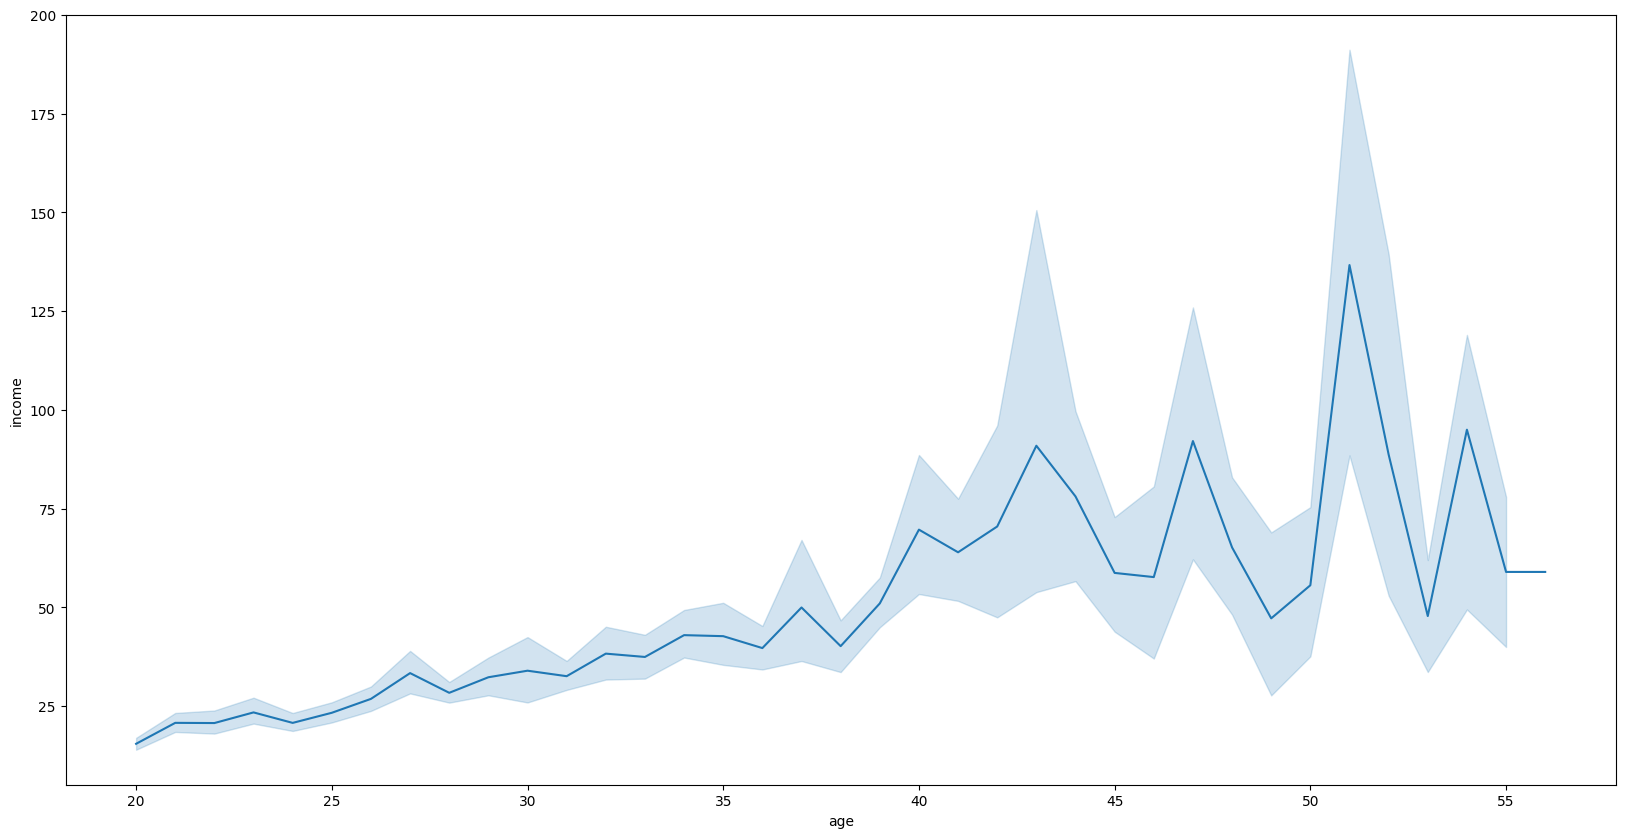

In [10]:
figure,axis= plt.subplots(figsize=(20,10))
sns.lineplot(x='age',y='income', data=df, ax=axis)

<Axes: xlabel='age', ylabel='debtinc'>

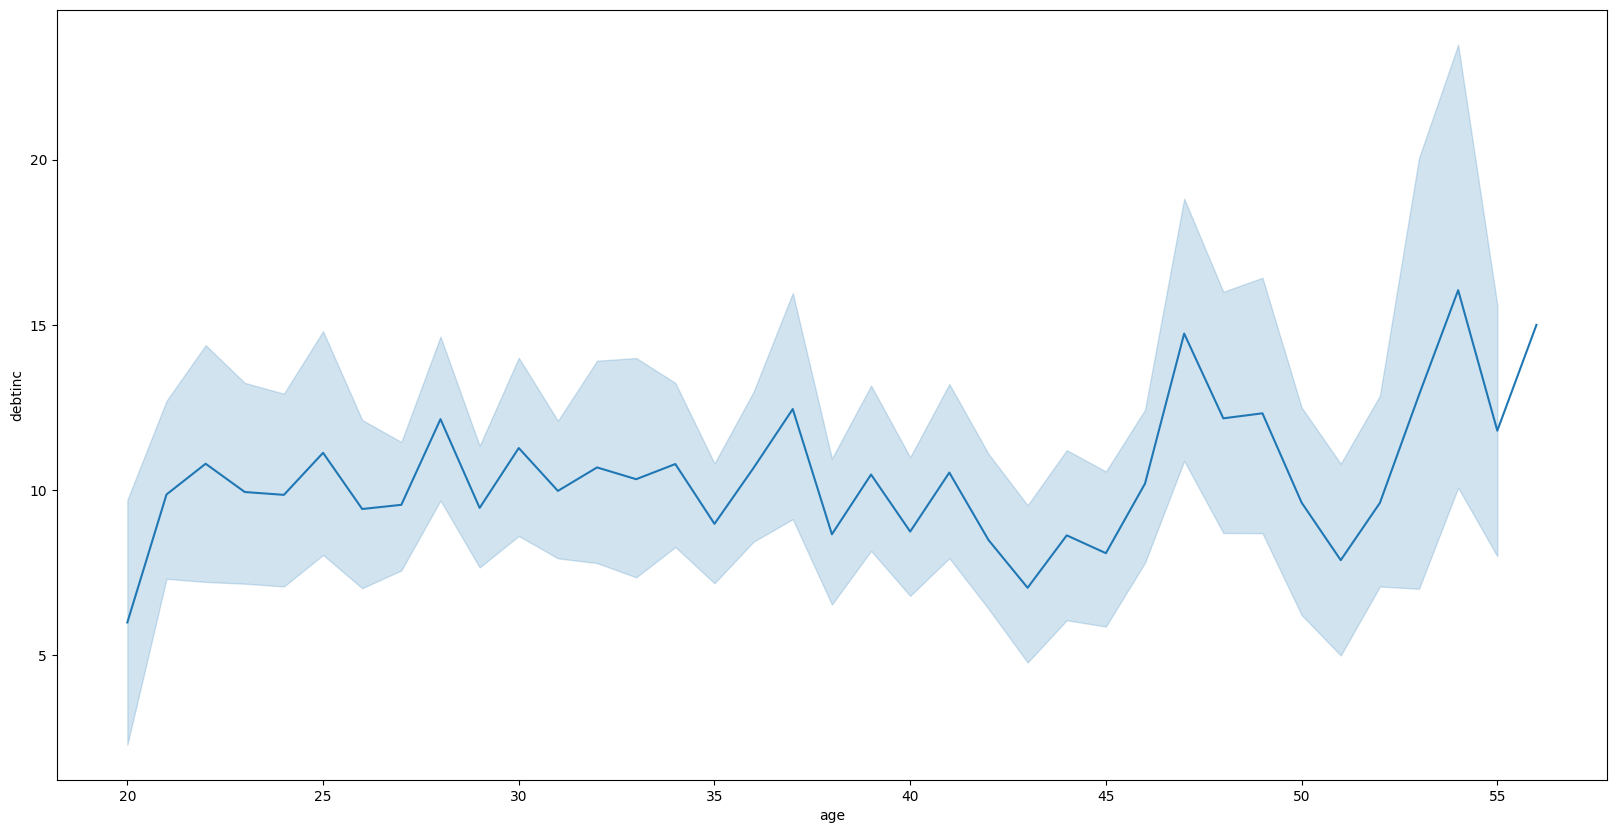

In [11]:
figure,axis= plt.subplots(figsize=(20,10))
sns.lineplot(x='age',y='debtinc', data=df, ax=axis)

In [12]:
df['default'].value_counts()

default
0.0    517
1.0    183
Name: count, dtype: int64

In [15]:
x=df.drop(['default'],axis=1)
y=df['default']

In [16]:
x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
sc=StandardScaler()
x_train= sc.fit_transform(x_train)
x_test=sc.transform(x_test)

***Model Creation– Random Forest***

In [21]:
rf=RandomForestClassifier(n_estimators=200)

In [22]:
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [26]:
rf.score(x_test,y_test)

0.7642857142857142

In [29]:
rf2 = cross_val_score(estimator=rf,X=x_train,y=y_train,cv=10)
rf2.mean()

np.float64(0.7857142857142857)

***Support Vector Machine***

In [31]:
sv=SVC()
sv.fit(x_train, y_train)

SVC()

In [32]:
sv.score(x_test,y_test)

0.8071428571428572

In [40]:
model= GridSearchCV(sv,{
    'C':[0.1,0.2,0.4,0.8,1.2,1.8,4,7],
    'gamma':[0.1,0.4,0.8,1.0,2.0,3.0],
    'kernel':['rbf','linear']
}, scoring='accuracy',cv=10)

In [41]:
model.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 0.2, 0.4, 0.8, 1.2, 1.8, 4, 7],
                         'gamma': [0.1, 0.4, 0.8, 1.0, 2.0, 3.0],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [42]:
model.best_params_

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}

In [43]:
model2 = SVC(C=0.1,gamma=0.1,kernel='linear')
model2.fit(x_train, y_train)
model2.score(x_test,y_test)

0.8357142857142857

In [44]:
lr= LogisticRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)

0.8571428571428571

<Axes: >

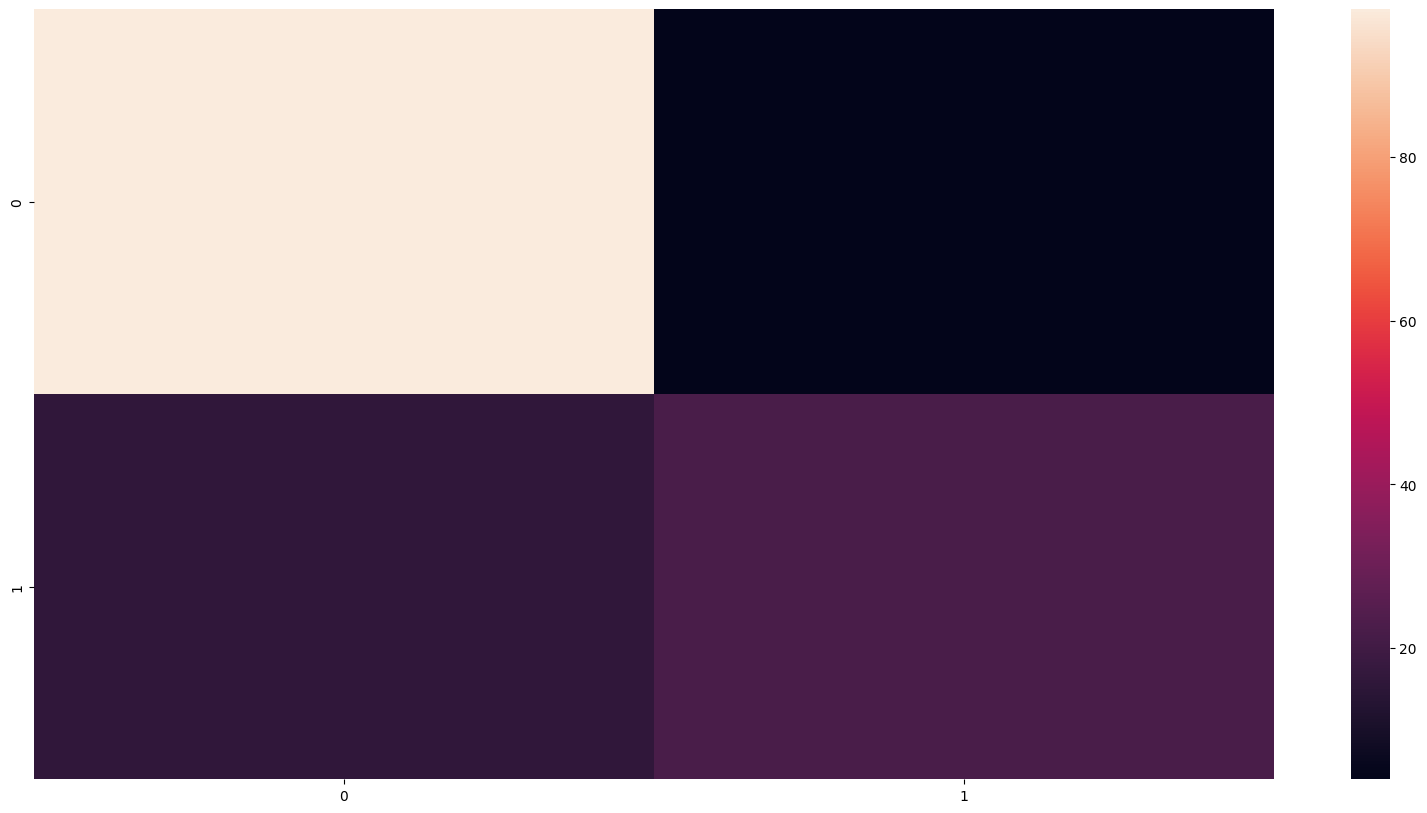

In [45]:
yp=lr.predict(x_test)
c=confusion_matrix(y_test,yp)

figure,axis=plt.subplots(figsize=(20,10))
sns.heatmap(c,ax=axis)